**Policy:** CnnPolicy | **Env:** ALE/Seaquest-v5

All outputs saved to `/kaggle/working/kerie/runs/`  
Download them manually after the notebook finishes via the **Output** tab.

In [8]:

import subprocess, sys

for pkg in ['ale-py', 'gymnasium[atari]', 'stable-baselines3', 'opencv-python', 'tensorboard']:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'  OK: {pkg}')
    except Exception as e:
        print(f'  FAILED: {pkg}')
        print(f'  -> Enable Internet: Settings â†’ Internet â†’ On, then re-run this cell')
        raise

print('\nAll packages installed successfully.')

  OK: ale-py
  OK: gymnasium[atari]
  OK: stable-baselines3
  OK: opencv-python
  OK: tensorboard

All packages installed successfully.


In [9]:
# ── 2. Imports ───────────────────────────────────────────────────
import os, csv, gc
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import torch

from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla P100-PCIE-16GB


In [10]:
# ── 3. Configuration ─────────────────────────────────────────────
ENV_ID          = 'ALE/Seaquest-v5'
BUFFER_SIZE     = 50_000    # reduced from 100k — saves ~3 GB RAM
LEARNING_STARTS = 10_000
TARGET_UPDATE   = 1_000
N_STACK         = 4
OUTPUT_DIR      = '/kaggle/working/kerie/runs'

# With memory fixes we can now afford more steps
TIMESTEPS_DEFAULT = 500_000
TIMESTEPS_FULL    = 1_000_000

EXPERIMENTS = {
    1:  dict(name='exp1_baseline_mid',             learning_rate=0.0001, gamma=0.94, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Baseline mid — good balance'),
    2:  dict(name='exp2_lr_bump',                  learning_rate=0.0002, gamma=0.94, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Slight lr bump — faster policy updates'),
    3:  dict(name='exp3_higher_gamma',             learning_rate=0.0001, gamma=0.95, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Higher gamma — values future rewards more'),
    4:  dict(name='exp4_lower_eps_start',          learning_rate=0.0003, gamma=0.94, batch_size=64, exploration_initial_eps=0.9, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Lower eps_start — less initial randomness'),
    5:  dict(name='exp5_lower_eps_end',            learning_rate=0.0001, gamma=0.96, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.02, exploration_fraction=0.10, notes='Lower eps_end — more greedy late stage'),
    6:  dict(name='exp6_faster_decay',             learning_rate=0.0002, gamma=0.95, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.05, notes='Faster decay — earlier shift to exploit'),
    7:  dict(name='exp7_slower_decay',             learning_rate=0.0001, gamma=0.94, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.25, notes='Slower decay — prolonged exploration'),
    8:  dict(name='exp8_mixed_mid',                learning_rate=0.0004, gamma=0.95, batch_size=64, exploration_initial_eps=0.9, exploration_final_eps=0.02, exploration_fraction=0.10, notes='Mixed mid — combined moderate changes'),
    9:  dict(name='exp9_moderate_decay_high_gamma',learning_rate=0.0003, gamma=0.96, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.15, notes='Moderate decay with higher gamma'),
    10: dict(name='exp10_best_of_mid',             learning_rate=0.0005, gamma=0.95, batch_size=64, exploration_initial_eps=0.9, exploration_final_eps=0.02, exploration_fraction=0.20, notes='Best-of-mid — final mid-range candidate ★ FULL 1M STEPS'),
}

print(f'Output: {OUTPUT_DIR}')
print(f'Exps 1-9 : {TIMESTEPS_DEFAULT:,} steps each')
print(f'Exp  10  : {TIMESTEPS_FULL:,} steps (full run)')
print(f'Buffer   : {BUFFER_SIZE:,} (optimize_memory_usage=True)')

Output: /kaggle/working/kerie/runs
Exps 1-9 : 500,000 steps each
Exp  10  : 1,000,000 steps (full run)
Buffer   : 50,000 (optimize_memory_usage=True)


In [11]:
def make_env(render_mode=None):
    def _init():
        env = gym.make(ENV_ID, render_mode=render_mode)
        env = AtariWrapper(env)
        return env
    vec_env = DummyVecEnv([_init])
    vec_env = VecFrameStack(vec_env, n_stack=N_STACK)
    return vec_env

In [12]:
# ── 5. Run one experiment ────────────────────────────────────────
#
# Memory optimization explained:
#   DQN's replay buffer stores transitions: (state, action, reward, next_state).
#   But next_state of transition N is identical to state of transition N+1,
#   so by default SB3 stores every frame TWICE — wasting half the buffer RAM.
#   Setting optimize_memory_usage=True avoids this duplication by reconstructing
#   next_state on the fly from the neighboring entry, cutting buffer memory ~50%.
#   Trade-off: sampling is slightly slower, but we save ~1.5 GB with buffer=50k.
#
#   Combined with gc.collect() + torch.cuda.empty_cache() between experiments,
#   this prevents the OOM crashes we hit when running 10 experiments sequentially.

def run_experiment(exp_id, total_timesteps=TIMESTEPS_DEFAULT):
    cfg     = EXPERIMENTS[exp_id]
    run_dir = os.path.join(OUTPUT_DIR, cfg['name'])

    print(f"\n{'='*60}")
    print(f"  Experiment {exp_id:02d}: {cfg['name']}")
    print(f"  Notes: {cfg['notes']}")
    print(f"  lr={cfg['learning_rate']}  gamma={cfg['gamma']}  batch={cfg['batch_size']}")
    print(f"  eps_start={cfg['exploration_initial_eps']}  eps_end={cfg['exploration_final_eps']}  eps_frac={cfg['exploration_fraction']}")
    print(f"{'='*60}")

    # Skip if already done
    done_path = os.path.join(run_dir, 'dqn_model.zip')
    if os.path.isfile(done_path):
        print(f'  SKIPPED — already completed')
        return done_path

    log_dir  = os.path.join(run_dir, 'tensorboard')
    eval_dir = os.path.join(run_dir, 'eval')
    os.makedirs(run_dir,  exist_ok=True)
    os.makedirs(log_dir,  exist_ok=True)
    os.makedirs(eval_dir, exist_ok=True)

    train_env = make_env()
    eval_env  = make_env()

    model = DQN(
        policy                  = 'CnnPolicy',
        env                     = train_env,
        learning_rate           = cfg['learning_rate'],
        gamma                   = cfg['gamma'],
        batch_size              = cfg['batch_size'],
        exploration_initial_eps = cfg['exploration_initial_eps'],
        exploration_final_eps   = cfg['exploration_final_eps'],
        exploration_fraction    = cfg['exploration_fraction'],
        buffer_size             = BUFFER_SIZE,
        learning_starts         = LEARNING_STARTS,
        target_update_interval  = TARGET_UPDATE,
        tensorboard_log         = log_dir,
        verbose                 = 1,
        optimize_memory_usage   = False,   # avoid storing next_state twice → ~50% less buffer RAM
    )

    early_stop = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=3, verbose=1
    )
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path = eval_dir,
        log_path             = eval_dir,
        eval_freq            = 25_000,
        n_eval_episodes      = 5,
        deterministic        = True,
        render               = False,
        callback_after_eval  = early_stop,
    )

    model.learn(
        total_timesteps     = total_timesteps,
        callback            = eval_callback,
        tb_log_name         = cfg['name'],
        reset_num_timesteps = False,
    )

    model_path = os.path.join(run_dir, 'dqn_model')
    model.save(model_path)
    print(f'\n  Model saved -> {model_path}.zip')

    train_env.close()
    eval_env.close()

    # ── Free memory between experiments ──
    # Without this, PyTorch/CUDA hold onto allocations from the previous
    # experiment and memory accumulates until OOM after ~8 runs.
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ── Save plot + CSV ──
    eval_npz = os.path.join(eval_dir, 'evaluations.npz')
    if os.path.isfile(eval_npz):
        data         = np.load(eval_npz)
        timesteps    = data['timesteps']
        mean_rewards = data['results'].mean(axis=1)
        std_rewards  = data['results'].std(axis=1)

        plt.figure(figsize=(10, 5))
        plt.plot(timesteps, mean_rewards, label='Mean Reward')
        plt.fill_between(timesteps,
                         mean_rewards - std_rewards,
                         mean_rewards + std_rewards,
                         alpha=0.3, label='Std Dev')
        plt.xlabel('Timesteps')
        plt.ylabel('Eval Reward')
        plt.title(f"Exp {exp_id:02d}: {cfg['name']}\n"
                  f"lr={cfg['learning_rate']} gamma={cfg['gamma']} "
                  f"batch={cfg['batch_size']} eps_frac={cfg['exploration_fraction']}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plot_path = os.path.join(run_dir, 'reward_plot.png')
        plt.savefig(plot_path, dpi=150)
        plt.show()
        plt.close()
        print(f'  Plot saved  -> {plot_path}')

        csv_path = os.path.join(run_dir, 'results.csv')
        with open(csv_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['timestep', 'mean_reward', 'std_reward'])
            for t, m, s in zip(timesteps, mean_rewards, std_rewards):
                writer.writerow([int(t), f'{m:.2f}', f'{s:.2f}'])
        print(f'  CSV saved   -> {csv_path}')

    return done_path


  Experiment 01: exp1_baseline_mid
  Notes: Baseline mid — good balance
  lr=0.0001  gamma=0.94  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.1
  SKIPPED — already completed

  Experiment 02: exp2_lr_bump
  Notes: Slight lr bump — faster policy updates
  lr=0.0002  gamma=0.94  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.1
  SKIPPED — already completed

  Experiment 03: exp3_higher_gamma
  Notes: Higher gamma — values future rewards more
  lr=0.0001  gamma=0.95  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.1
  SKIPPED — already completed

  Experiment 04: exp4_lower_eps_start
  Notes: Lower eps_start — less initial randomness
  lr=0.0003  gamma=0.94  batch=64
  eps_start=0.9  eps_end=0.05  eps_frac=0.1
  SKIPPED — already completed

  Experiment 05: exp5_lower_eps_end
  Notes: Lower eps_end — more greedy late stage
  lr=0.0001  gamma=0.96  batch=64
  eps_start=1.0  eps_end=0.02  eps_frac=0.1
  SKIPPED — already completed

  Experiment 06: exp6_faster_decay
  Notes: F

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x780370403170> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7803f9bb48f0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 295      |
|    time_elapsed     | 0        |
|    total_timesteps  | 152      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 293      |
|    time_elapsed     | 0        |
|    total_timesteps  | 225      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 293      |
|    time_elapsed     | 1        |
|    total_timesteps  | 304      |
----------------------------------
----------------------------------
| rollout/          

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=25000, episode_reward=4.20 +/- 4.45
Episode length: 53.60 +/- 43.26
----------------------------------
| eval/               |          |
|    mean_ep_length   | 53.6     |
|    mean_reward      | 4.2      |
| rollout/            |          |
|    exploration_rate | 0.683    |
| time/               |          |
|    total_timesteps  | 25000    |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.0441   |
|    n_updates        | 3749     |
----------------------------------
New best mean reward!
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.682    |
| time/               |          |
|    episodes         | 892      |
|    fps              | 238      |
|    time_elapsed     | 105      |
|    total_timesteps  | 25072    |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.0782   |
|    n_updates        | 3767     |
----------------

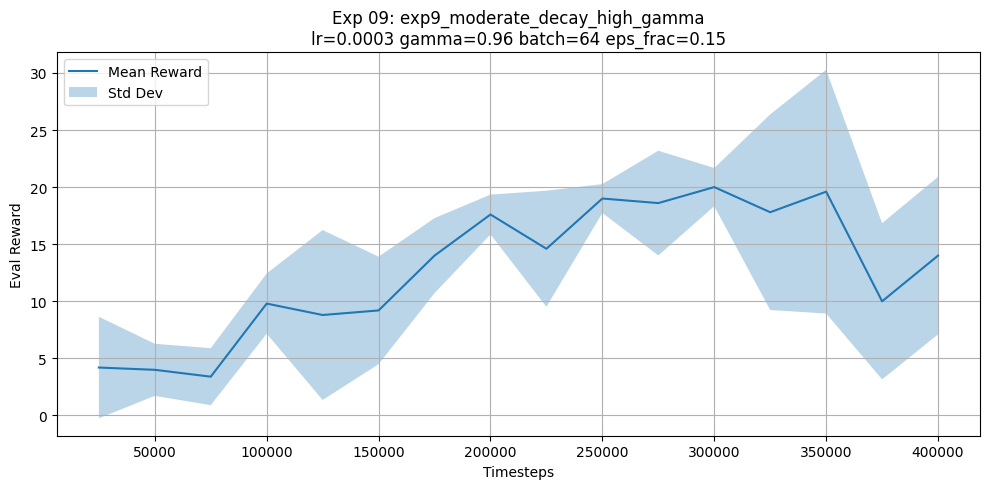

  Plot saved  -> /kaggle/working/kerie/runs/exp9_moderate_decay_high_gamma/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp9_moderate_decay_high_gamma/results.csv

  Experiment 10: exp10_best_of_mid
  Notes: Best-of-mid — final mid-range candidate ★ FULL 1M STEPS
  lr=0.0005  gamma=0.95  batch=64
  eps_start=0.9  eps_end=0.02  eps_frac=0.2
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp10_best_of_mid/tensorboard/exp10_best_of_mid_0


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7802b8b73950> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7802b8929b20>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.899    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 315      |
|    time_elapsed     | 0        |
|    total_timesteps  | 160      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.899    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 310      |
|    time_elapsed     | 0        |
|    total_timesteps  | 253      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.898    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 315      |
|    time_elapsed     | 1        |
|    total_timesteps  | 391      |
----------------------------------
----------------------------------
| rollout/          

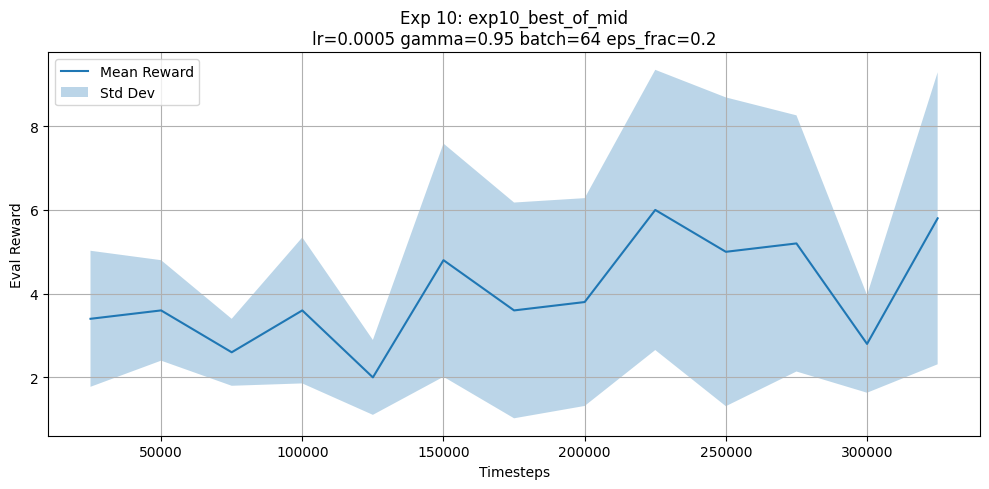

  Plot saved  -> /kaggle/working/kerie/runs/exp10_best_of_mid/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp10_best_of_mid/results.csv
ALL EXPERIMENTS COMPLETE
  Exp 01: /kaggle/working/kerie/runs/exp1_baseline_mid/dqn_model.zip
  Exp 02: /kaggle/working/kerie/runs/exp2_lr_bump/dqn_model.zip
  Exp 03: /kaggle/working/kerie/runs/exp3_higher_gamma/dqn_model.zip
  Exp 04: /kaggle/working/kerie/runs/exp4_lower_eps_start/dqn_model.zip
  Exp 05: /kaggle/working/kerie/runs/exp5_lower_eps_end/dqn_model.zip
  Exp 06: /kaggle/working/kerie/runs/exp6_faster_decay/dqn_model.zip
  Exp 07: /kaggle/working/kerie/runs/exp7_slower_decay/dqn_model.zip
  Exp 08: /kaggle/working/kerie/runs/exp8_mixed_mid/dqn_model.zip
  Exp 09: /kaggle/working/kerie/runs/exp9_moderate_decay_high_gamma/dqn_model.zip
  Exp 10: /kaggle/working/kerie/runs/exp10_best_of_mid/dqn_model.zip


In [13]:
# ── 6. Run all 10 experiments ────────────────────────────────────
# Exps 1-9 → 200k steps each | Exp 10 → 1M steps
# Finished experiments are skipped automatically on re-run.

results = {}
for exp_id in EXPERIMENTS:
    timesteps = TIMESTEPS_FULL if exp_id == 10 else TIMESTEPS_DEFAULT
    path = run_experiment(exp_id, total_timesteps=timesteps)
    results[exp_id] = path

print('ALL EXPERIMENTS COMPLETE')
for exp_id, path in results.items():
    print(f'  Exp {exp_id:02d}: {path}')
print('='*60)

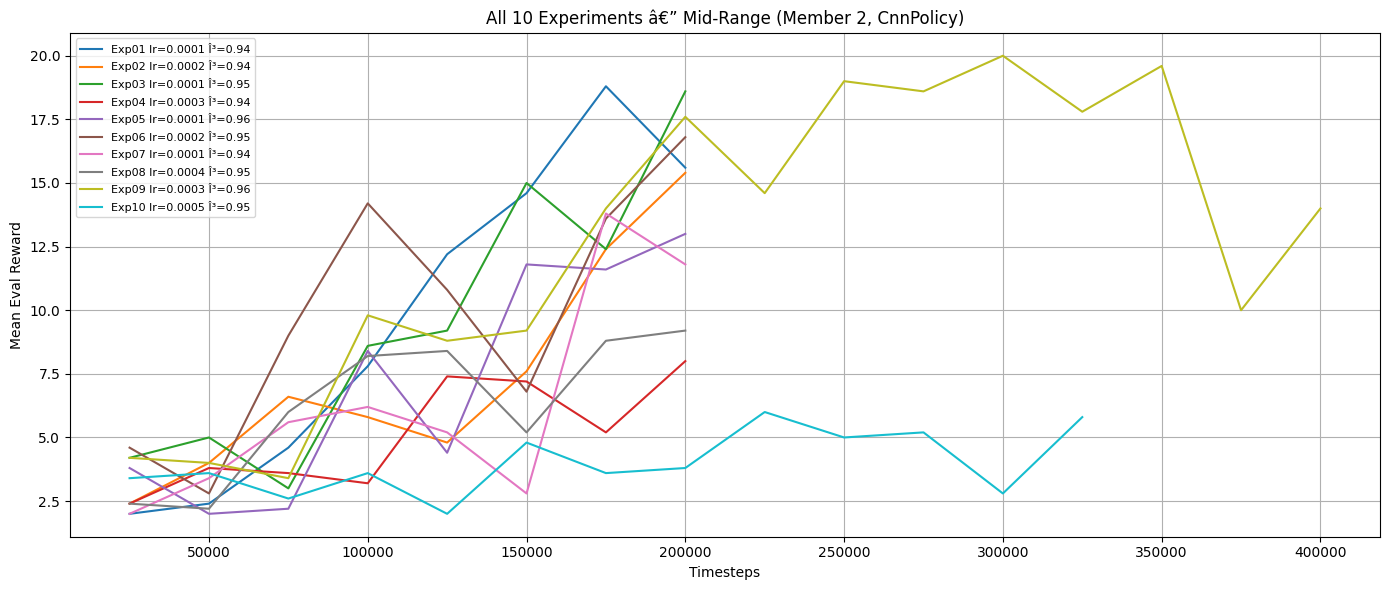

Summary plot saved -> /kaggle/working/kerie/runs/summary_all_experiments.png


In [14]:
# â”€â”€ 7. Summary comparison plot (all experiments) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
plt.figure(figsize=(14, 6))

for exp_id, cfg in EXPERIMENTS.items():
    eval_npz = os.path.join(OUTPUT_DIR, cfg['name'], 'eval', 'evaluations.npz')
    if not os.path.isfile(eval_npz):
        continue
    data         = np.load(eval_npz)
    timesteps    = data['timesteps']
    mean_rewards = data['results'].mean(axis=1)
    plt.plot(timesteps, mean_rewards, label=f"Exp{exp_id:02d} lr={cfg['learning_rate']} Î³={cfg['gamma']}")

plt.xlabel('Timesteps')
plt.ylabel('Mean Eval Reward')
plt.title('All 10 Experiments â€” Mid-Range (Member 2, CnnPolicy)')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
summary_path = os.path.join(OUTPUT_DIR, 'summary_all_experiments.png')
plt.savefig(summary_path, dpi=150)
plt.show()
print(f'Summary plot saved -> {summary_path}')

In [15]:
print(f"{'Exp':<5} {'Name':<40} {'Best Reward':>12} {'Final Reward':>13}")
print('-' * 75)

summary_rows = []
for exp_id, cfg in EXPERIMENTS.items():
    eval_npz = os.path.join(OUTPUT_DIR, cfg['name'], 'eval', 'evaluations.npz')
    if not os.path.isfile(eval_npz):
        print(f"{exp_id:<5} {cfg['name']:<40} {'NOT DONE':>12}")
        continue
    data         = np.load(eval_npz)
    mean_rewards = data['results'].mean(axis=1)
    best_reward  = mean_rewards.max()
    final_reward = mean_rewards[-1]
    print(f"{exp_id:<5} {cfg['name']:<40} {best_reward:>12.1f} {final_reward:>13.1f}")
    summary_rows.append([exp_id, cfg['name'], cfg['learning_rate'], cfg['gamma'],
                         cfg['batch_size'], cfg['exploration_initial_eps'],
                         cfg['exploration_final_eps'], cfg['exploration_fraction'],
                         f'{best_reward:.1f}', f'{final_reward:.1f}', cfg['notes']])

# Save summary CSV
summary_csv = os.path.join(OUTPUT_DIR, 'summary_table.csv')
with open(summary_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['exp', 'name', 'lr', 'gamma', 'batch', 'eps_start', 'eps_end', 'eps_frac', 'best_reward', 'final_reward', 'notes'])
    writer.writerows(summary_rows)
print(f'\nSummary CSV saved -> {summary_csv}')
print('\nDownload all outputs from the Output tab on the right ->')

Exp   Name                                      Best Reward  Final Reward
---------------------------------------------------------------------------
1     exp1_baseline_mid                                18.8          15.6
2     exp2_lr_bump                                     15.4          15.4
3     exp3_higher_gamma                                18.6          18.6
4     exp4_lower_eps_start                              8.0           8.0
5     exp5_lower_eps_end                               13.0          13.0
6     exp6_faster_decay                                16.8          16.8
7     exp7_slower_decay                                13.8          11.8
8     exp8_mixed_mid                                    9.2           9.2
9     exp9_moderate_decay_high_gamma                   20.0          14.0
10    exp10_best_of_mid                                 6.0           5.8

Summary CSV saved -> /kaggle/working/kerie/runs/summary_table.csv

Download all outputs from the Output tab o

In [2]:
!zip -r runs.zip /kaggle/working/kerie/runs

updating: kaggle/working/kerie/runs/ (stored 0%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/ (stored 0%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/tensorboard/ (stored 0%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/tensorboard/exp5_lower_eps_end_1/ (stored 0%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/tensorboard/exp5_lower_eps_end_1/events.out.tfevents.1773955177.fd43fce5b887.55.4 (deflated 76%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/reward_plot.png (deflated 10%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/eval/ (stored 0%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/eval/evaluations.npz (deflated 71%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/eval/best_model.zip (stored 0%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/dqn_model.zip (stored 0%)
updating: kaggle/working/kerie/runs/exp5_lower_eps_end/results.csv (deflated 37%)
updating: kaggle/working/kerie/runs/exp8_mixed_mid